In [1]:
# ==============================================================================
# [ CELDA 1 ] : IMPORTS, STYLE & CORE FUNCTIONS
# ==============================================================================
%matplotlib widget
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. STYLE CONFIGURATION ---
poster_style = {
    "figsize": (4, 4), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1.0,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

# --- 2. PIPELINE FUNCTIONS ---
def TrimSpectra(spectra_input, xmin, xmax):
    trimmed = {}
    for name, df in spectra_input.items():
        mask = (df["RamanShift"] >= xmin) & (df["RamanShift"] <= xmax)
        trimmed[name] = df[mask].copy().reset_index(drop=True)
    return trimmed

def NormalizeSpectra(spectra_input, xmin=None, xmax=None, mode="M"):
    normalized = {}
    for name, df in spectra_input.items():
        df_norm = df.copy()
        X = df_norm["RamanShift"].values
        Y = df_norm["Intensity"].values
        
        if xmin is not None and xmax is not None:
            mask = (X >= xmin) & (X <= xmax)
        else:
            mask = np.ones_like(X, dtype=bool)
            
        X_window = X[mask]
        Y_window = Y[mask]
        
        if len(X_window) == 0: continue
            
        if mode.upper() == "M": factor = np.max(Y_window)
        elif mode.upper() == "I": factor = np.trapezoid(Y_window, X_window)
        elif mode.upper() == "V": factor = np.min(Y_window)
        else: raise ValueError("Mode must be 'M', 'I', or 'V'")
            
        if factor == 0: continue
        df_norm["Intensity"] = Y / factor
        normalized[name] = df_norm
    return normalized

def PlotRaman(
        spectra_dict, spectra_names, style=poster_style, offset_step=0.0, 
        xmin=None, xmax=None, ymin=None, ymax=None, 
        xlabel="Raman shift (cm$^{-1}$)", ylabel="Intensity (a.u.)",
        custom_labels=None, custom_colors=None, custom_linestyles=None, 
        vlines=None, hide_yticks=False, legend_ncol=1
):
    fig, ax1 = plt.subplots(figsize=style["figsize"], dpi=style["dpi"])
    plt.rcParams.update({"font.size": style["font_size"], "font.family": style["font_family"]})
    
    default_colors = style.get("colors") or ["#000000"]
    default_linestyles = style.get("linestyles") or ["-"]
    
    for i, name in enumerate(spectra_names):
        if name not in spectra_dict: continue
            
        df = spectra_dict[name]
        label = custom_labels[i] if custom_labels and i < len(custom_labels) else name
        X = df["RamanShift"].values
        Y = df["Intensity"].values + (i * offset_step)
        
        c = custom_colors[i] if custom_colors and i < len(custom_colors) else default_colors[i % len(default_colors)]
        ls = custom_linestyles[i] if custom_linestyles and i < len(custom_linestyles) else default_linestyles[i % len(default_linestyles)]
        
        ax1.plot(X, Y, label=label, linewidth=style["line_width"], color=c, linestyle=ls)

    ax1.set_xlabel(xlabel, fontsize=style["label_size"])
    ax1.set_ylabel(ylabel, fontsize=style["label_size"])
    
    if xmin is not None or xmax is not None: ax1.set_xlim(xmin, xmax)
    if ymin is not None or ymax is not None: ax1.set_ylim(ymin, ymax)
    if style.get("grid", False): ax1.grid(True, alpha=0.3)
    if hide_yticks: ax1.set_yticklabels([])

    if vlines is not None:
        for x_val in vlines:
            ax1.axvline(x=x_val, linewidth=0.5, linestyle='--', color='black', alpha=0.7, zorder=0)
            
    ax1.legend(fontsize=style["legend_size"], ncol=legend_ncol)
    plt.tight_layout()
    plt.show()

# --- 3. THE WRAPPER FUNCTION ---
def PlotRamanConfig(config, spectra_dict, offset_step=0.0, 
                    xmin=None, xmax=None, ymin=None, ymax=None, 
                    norm_xmin=None, norm_xmax=None, norm_mode="M",
                    hide_yticks=False, legend_ncol=1, vlines=None, style=poster_style):
    
    selected_list = [item[0] for item in config]
    clean_labels = [item[1] for item in config]
    custom_colors = [item[2] for item in config]
    custom_linestyles = [item[3] for item in config]
    
    selected_spectra = {name: spectra_dict[name] for name in selected_list if name in spectra_dict}
    selected_spectra = NormalizeSpectra(selected_spectra, xmin=norm_xmin, xmax=norm_xmax, mode=norm_mode)
    
    PlotRaman(
        spectra_dict=selected_spectra, 
        spectra_names=selected_list,
        custom_labels=clean_labels,
        custom_colors=custom_colors,
        custom_linestyles=custom_linestyles,
        offset_step=offset_step,
        xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
        style=style, hide_yticks=hide_yticks, 
        legend_ncol=legend_ncol, vlines=vlines
    )



In [2]:
# ==============================================================================
# [ CELDA 2 ] : LOAD DATA (Directorio 20260818)
# ==============================================================================

target_dirs = [
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260818_FilledCNTs_CF_P2_F005LP_F006WA_F007WA"
]

raman_spectra = {}

for folder in target_dirs:
    print(f"\nReading folder: {folder}")
    for root, dirs, files in os.walk(folder):
        for file in files:
            if not file.lower().endswith(".txt"): continue
            path = os.path.join(root, file)
            
            try:
                df = pd.read_csv(path, sep="\t", comment="#", header=None, encoding="latin1", usecols=[0, 1])
                df.columns = ["RamanShift", "Intensity"]
                df["RamanShift"] = pd.to_numeric(df["RamanShift"], errors="coerce")
                df["Intensity"] = pd.to_numeric(df["Intensity"], errors="coerce")
                df = df.dropna().sort_values("RamanShift").reset_index(drop=True)
                
                raman_spectra[file] = df
            except Exception as e:
                pass
                
print(f"Loaded {len(raman_spectra)} spectra successfully.")




Reading folder: H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260818_FilledCNTs_CF_P2_F005LP_F006WA_F007WA
Loaded 26 spectra successfully.


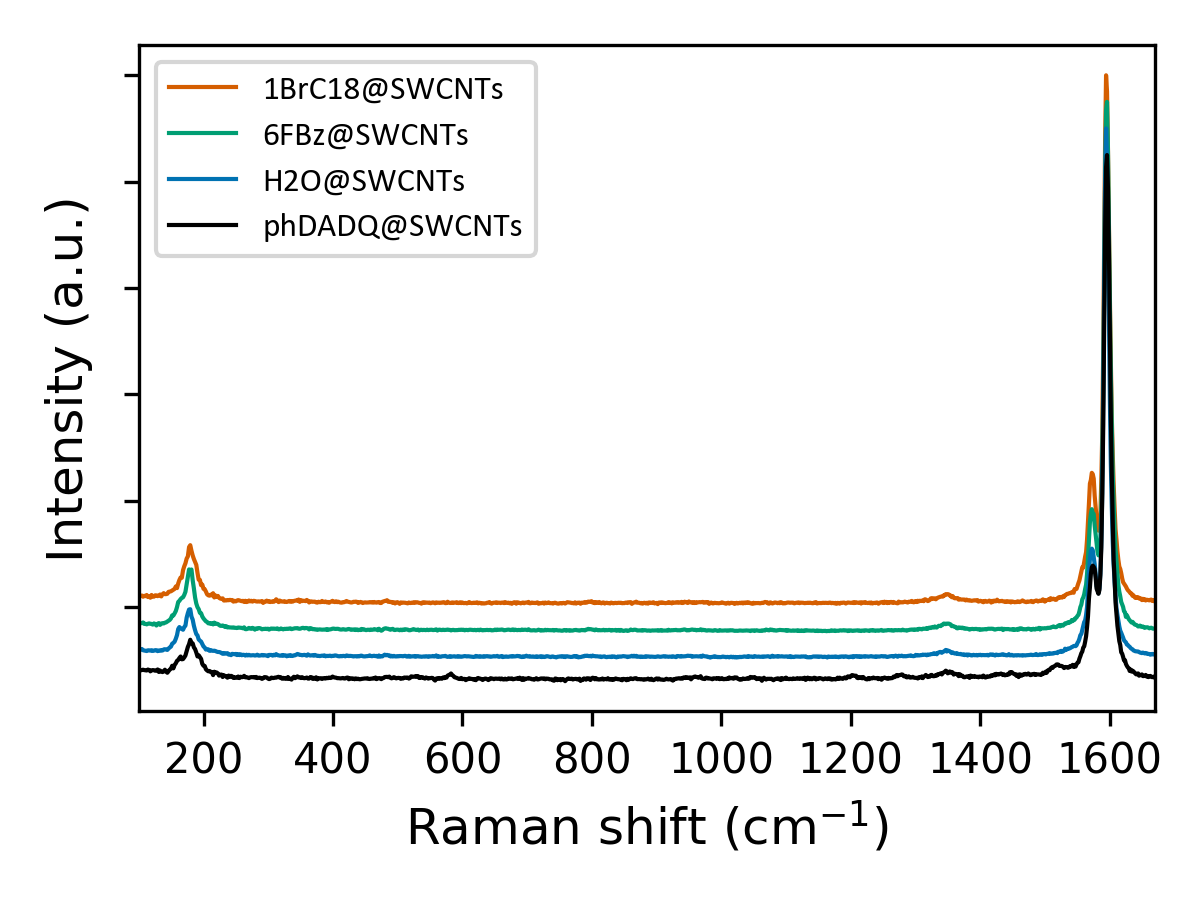

In [3]:
# ==============================================================================
# [ CELDA 3 ] : 532 nm - Región RBM (sc875)
# ==============================================================================

poster_style = {
    "figsize": (4,3), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}


raman_config_532_RBM = [
    ("260818_F007WA_1BrC18@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt", "1BrC18@SWCNTs", "#D55E00", "-"),
    ("260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",   "6FBz@SWCNTs",   "#009E73", "-"),
    ("260818_P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",               "H2O@SWCNTs",    "#0072B2", "-"),
    ("260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt", "phDADQ@SWCNTs", "#000000", "-"),

]

PlotRamanConfig(config=raman_config_532_RBM, 
                spectra_dict=raman_spectra, 
                hide_yticks=True, 
                style=poster_style,
                offset_step=-0.05,
                xmin=100,
                xmax=1670)



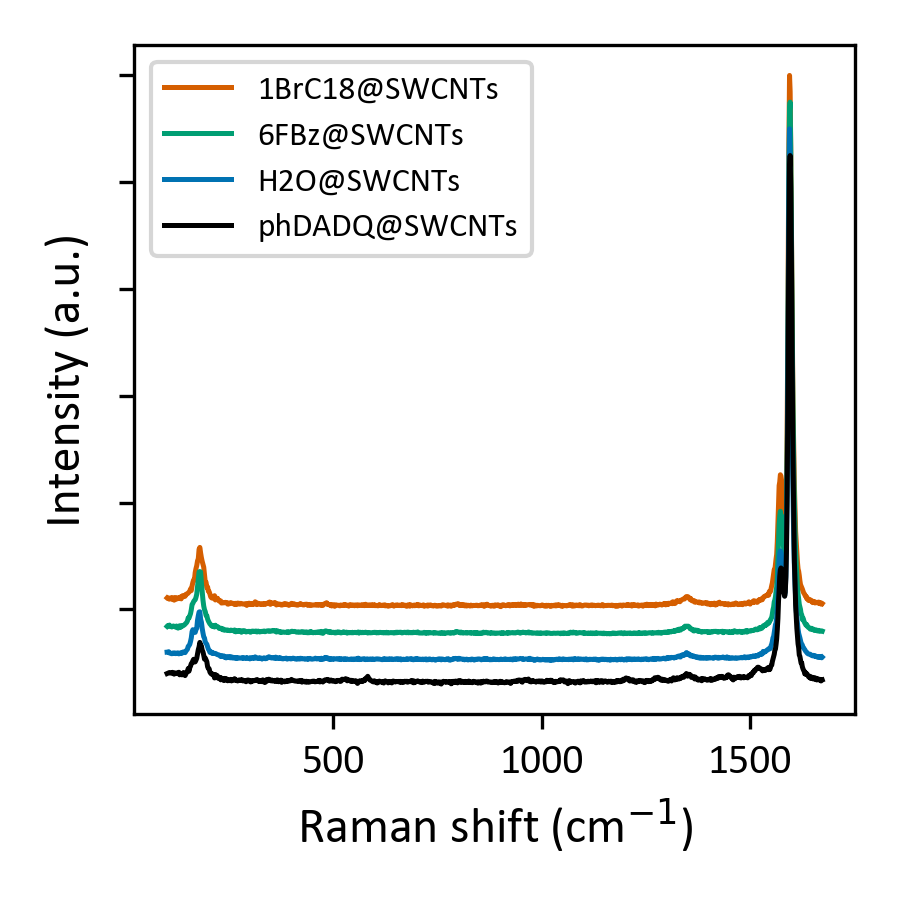

In [4]:
# ==============================================================================
# [ CELDA 3 ] : 532 nm - Región RBM (sc875)
# ==============================================================================

poster_style = {
    "figsize": (3, 3), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1.2,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}


raman_config_532_RBM = [
    ("260818_F007WA_1BrC18@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt", "1BrC18@SWCNTs", "#D55E00", "-"),
    ("260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",   "6FBz@SWCNTs",   "#009E73", "-"),
    ("260818_P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",               "H2O@SWCNTs",    "#0072B2", "-"),
    ("260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt", "phDADQ@SWCNTs", "#000000", "-"),

]

PlotRamanConfig(config=raman_config_532_RBM, 
                spectra_dict=raman_spectra, 
                hide_yticks=True, 
                style=poster_style,
                offset_step=-0.05,
                #xmin=1500,
                #xmax=1650
                )



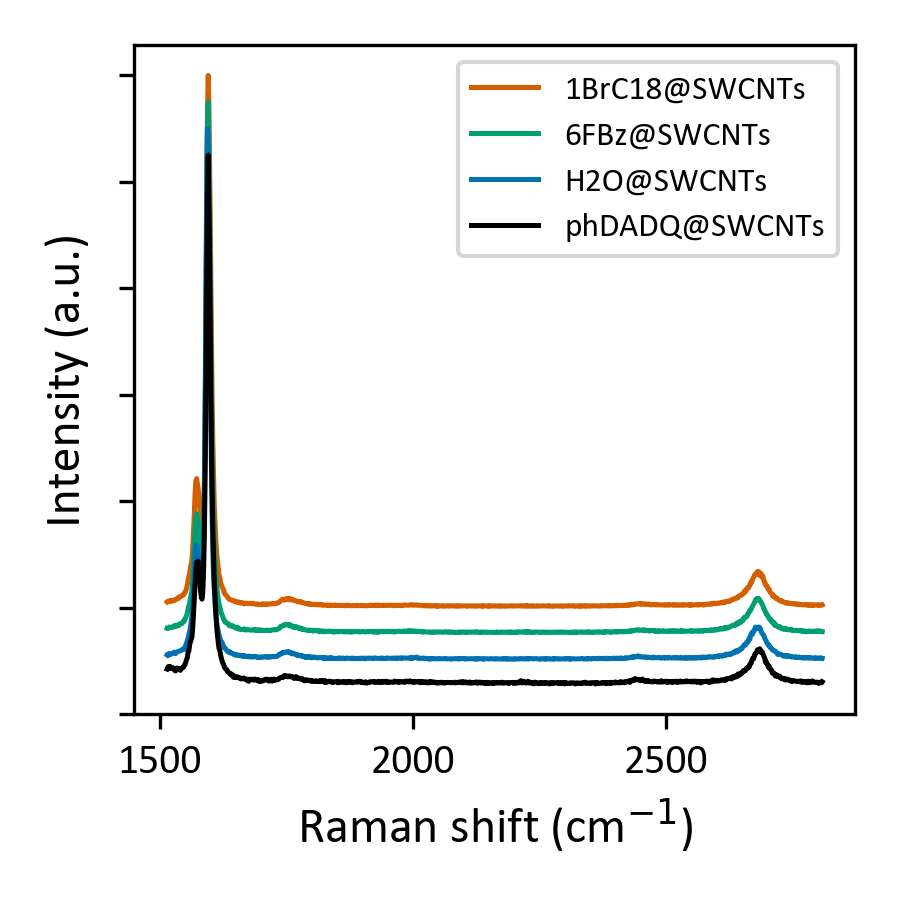

In [5]:
# ==============================================================================
# [ CELDA 4 ] : 532 nm - Región 2D-Band (sc2150)
# ==============================================================================
poster_style = {
    "figsize": (3, 3), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1.2,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}
raman_config_532_2D = [
    ("260818_F007WA_1BrC18@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt", "1BrC18@SWCNTs", "#D55E00", "-"),
    ("260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",   "6FBz@SWCNTs",   "#009E73", "-"),
    ("260818_P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",               "H2O@SWCNTs",    "#0072B2", "-"),
    ("260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt", "phDADQ@SWCNTs", "#000000", "-"),

]

PlotRamanConfig(config=raman_config_532_2D, 
                spectra_dict=raman_spectra, 
                hide_yticks=True                
                ,style=poster_style,
                offset_step=-0.05,
                #xmin=1500,
                #xmax=1650
                )




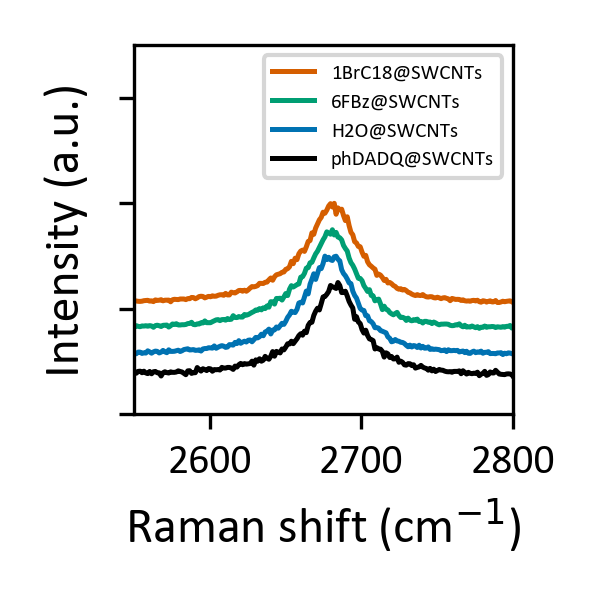

In [6]:
poster_style = {
    "figsize": (2,2), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 5,
    "line_width": 1.2,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

PlotRamanConfig(config=raman_config_532_2D, 
                spectra_dict=raman_spectra, 
                hide_yticks=True,
                style=poster_style,
                offset_step=-0.25,
                norm_xmax=2800,
                norm_xmin=2400,
                xmin=2550,
                xmax=2800,
                ymax=2.5,
                ymin=-1
                )


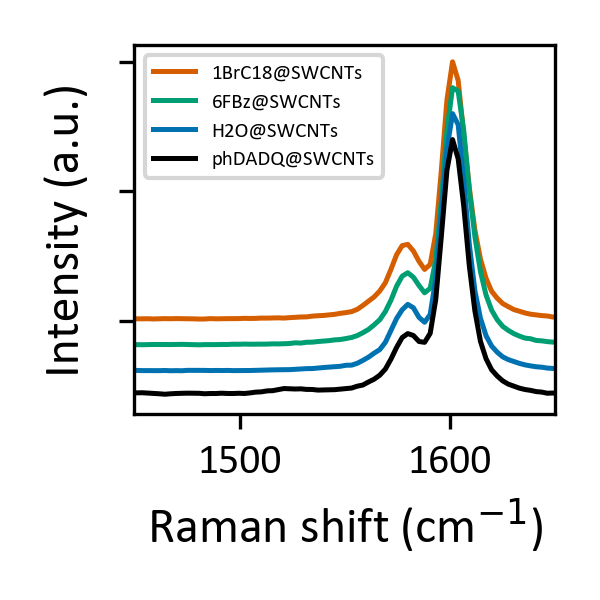

In [7]:
# ==============================================================================
# [ CELDA 5 ] : 532 nm - Región G-Band (sc1350)
# ==============================================================================
raman_config_532_G = [
    ("260818_F007WA_1BrC18@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt", "1BrC18@SWCNTs", "#D55E00", "-"),
    ("260818_F005LP_6FBz@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",   "6FBz@SWCNTs",   "#009E73", "-"),
    ("260818_P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",               "H2O@SWCNTs",    "#0072B2", "-"),
        ("260818_F006WA_phDADQ@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt", "phDADQ@SWCNTs", "#000000", "-"),

]

poster_style = {
    "figsize": (2,2), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 5,
    "line_width": 1.2,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

PlotRamanConfig(config=raman_config_532_G, 
                spectra_dict=raman_spectra, 
                hide_yticks=True                
                ,style=poster_style,
                offset_step=-0.1,
                xmin=1450,
                xmax=1650
                )


In [8]:
# ==============================================================================
# [ CELDA 6 ] : 638 nm - TFE y 6FIPA
# ==============================================================================
raman_config_638_TFE = [
    ("260818_F003_TFE@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960_01.txt", "TFE@SWCNTs",   "#CC79A7", "-"),
    ("260818_F004_6FIPA@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",  "6FIPA@SWCNTs", "#E69F00", "-"),
]
if 1==0:
    PlotRamanConfig(config=raman_config_638_TFE, spectra_dict=raman_spectra, hide_yticks=True)



In [9]:
# ==============================================================================
# [ CELDA 7 ] : 638 nm - DGU Fractions (sc960) normalizadas por G-band
# ==============================================================================
raman_config_638_DGU = [
    ("260818_F007WA_1BrC18@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt", "1BrC18 (DGU)", "#D55E00", "-"),
    ("260818_F006WA_phDADQ@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt", "phDADQ (DGU)", "#000000", "-"),
    ("260818_F005LP_6FBz@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",   "6FBz (DGU)",   "#009E73", "-"),
    ("260818_P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",               "H2O (DGU)",    "#0072B2", "-"),
]

if 1==0:
    PlotRamanConfig(
        config=raman_config_638_DGU, 
        spectra_dict=raman_spectra, 
        offset_step=0.5, 
        ymax=10,
        norm_xmin=1250,      
        norm_xmax=1750,
        hide_yticks=True
    )



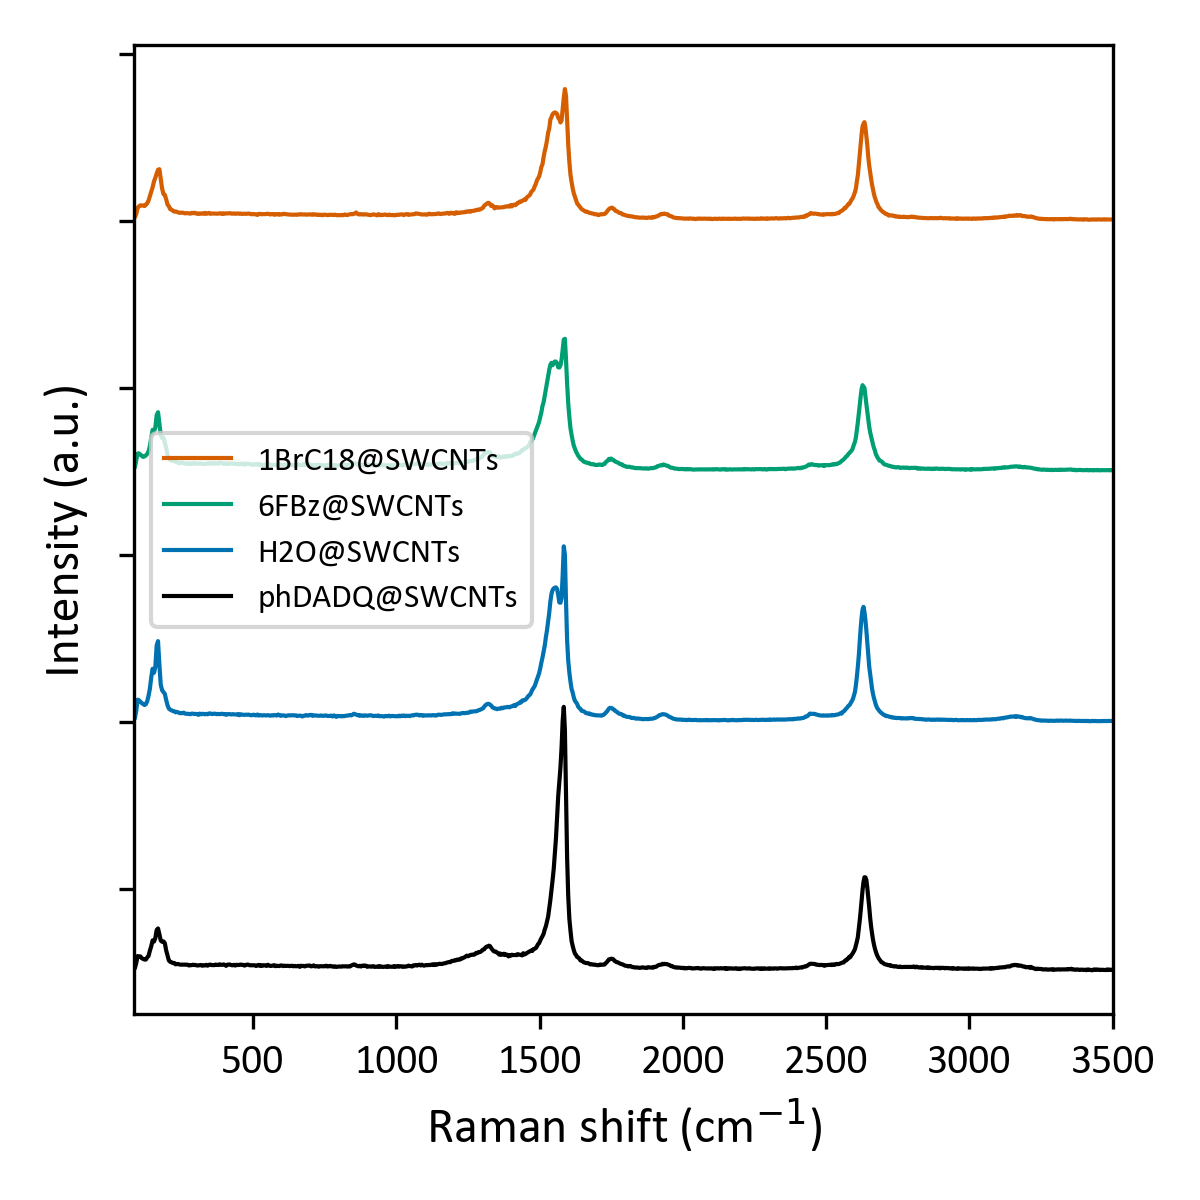

In [10]:
# ==============================================================================
# [ CELDA 8 ] : 638 nm - CFDrop (sc1870) normalizada por 2D-Band
# ==============================================================================
raman_config_638_sc1870 = [
    ("260818_F007WA_1BrC18@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt", "1BrC18@SWCNTs", "#D55E00", "-"),
    ("260818_F005LP_6FBz@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",   "6FBz@SWCNTs",   "#009E73", "-"),
    ("260818_P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",               "H2O@SWCNTs",    "#0072B2", "-"),
    ("260818_F006WA_phDADQ@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt", "phDADQ@SWCNTs", "#000000", "-"),

]


poster_style = {
    "figsize": (3, 3), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1.2,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}


PlotRamanConfig(
    config=raman_config_638_sc1870, 
    spectra_dict=raman_spectra, 
    offset_step=-30, 
    #ymax=5,
    norm_xmin=805,     
    norm_xmax=892,
    hide_yticks=True,
    xmin=86,
    xmax=3500
)


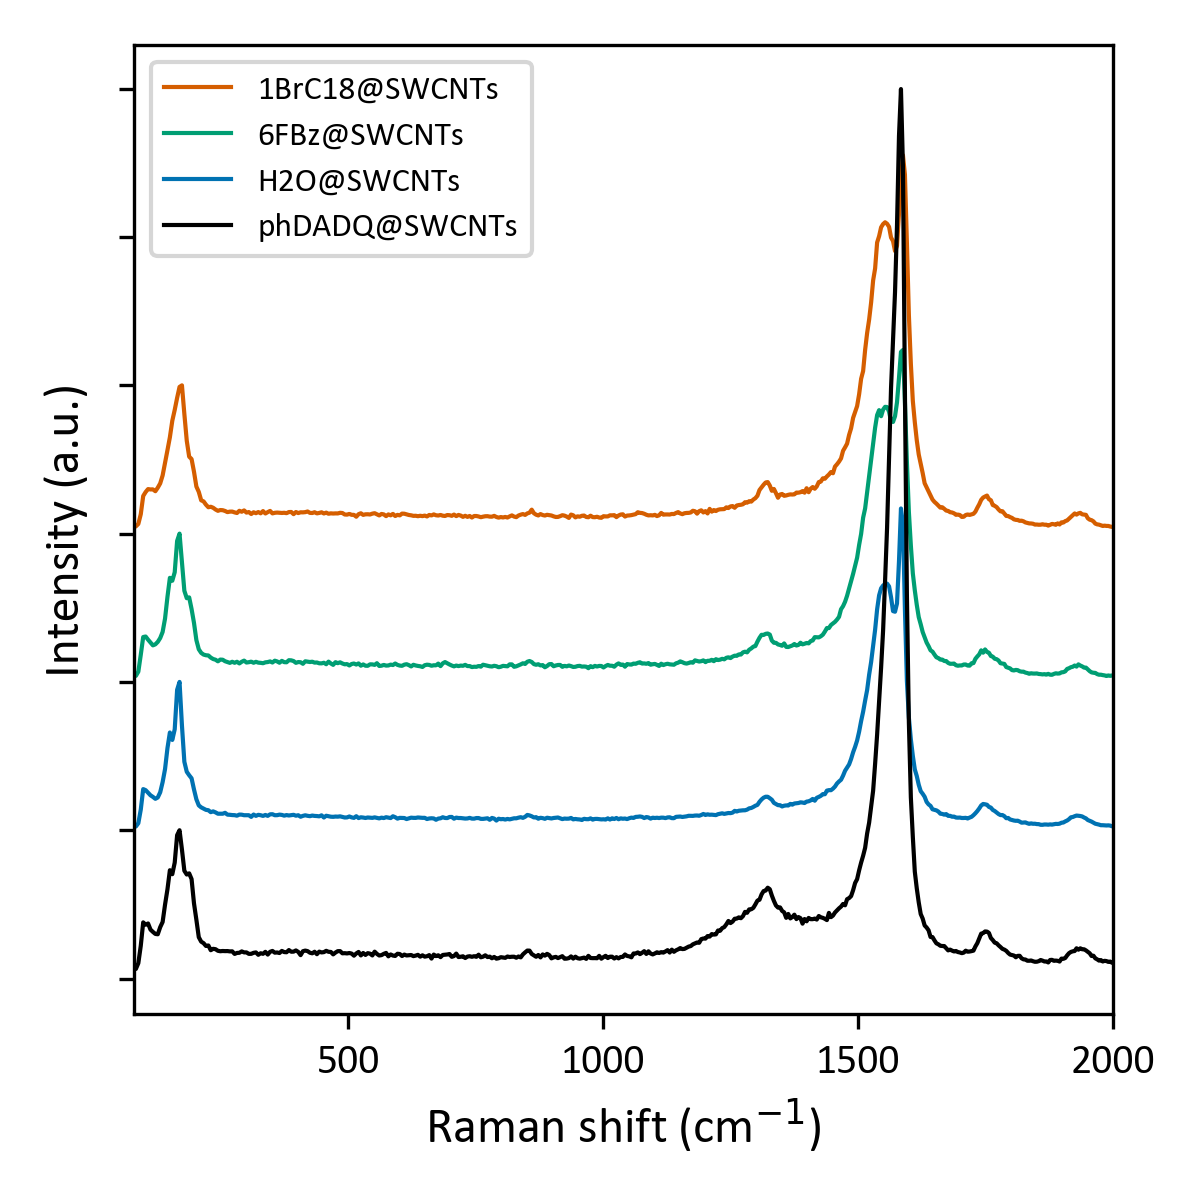

In [11]:
poster_style = {
    "figsize": (3, 3), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1.2,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}


PlotRamanConfig(
    config=raman_config_638_sc1870, 
    spectra_dict=raman_spectra, 
    offset_step=-1, 
    #ymax=5,
    norm_xmin=0,     
    norm_xmax=250,
    hide_yticks=True,
    xmin=80,
    xmax=2000
)

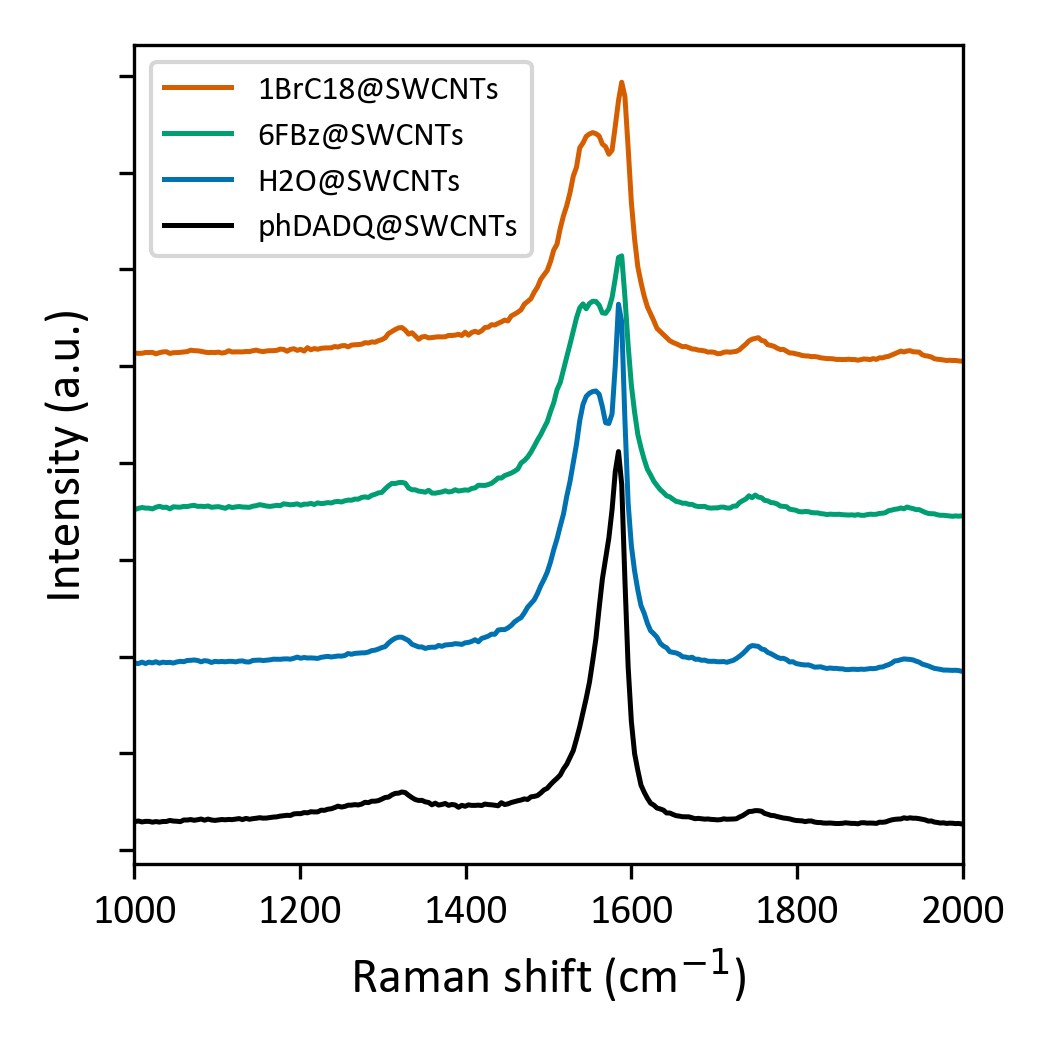

In [12]:
poster_style = {
    "figsize": (3.5,3.5), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1.2,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}



PlotRamanConfig(
    config=raman_config_638_sc1870, 
    spectra_dict=raman_spectra, 
    style=poster_style,
    offset_step=-4, 
    #ymax=5,
    norm_xmin=1200,     
    norm_xmax=1350,
    hide_yticks=True,
    xmin=1000,
    xmax=2000
)


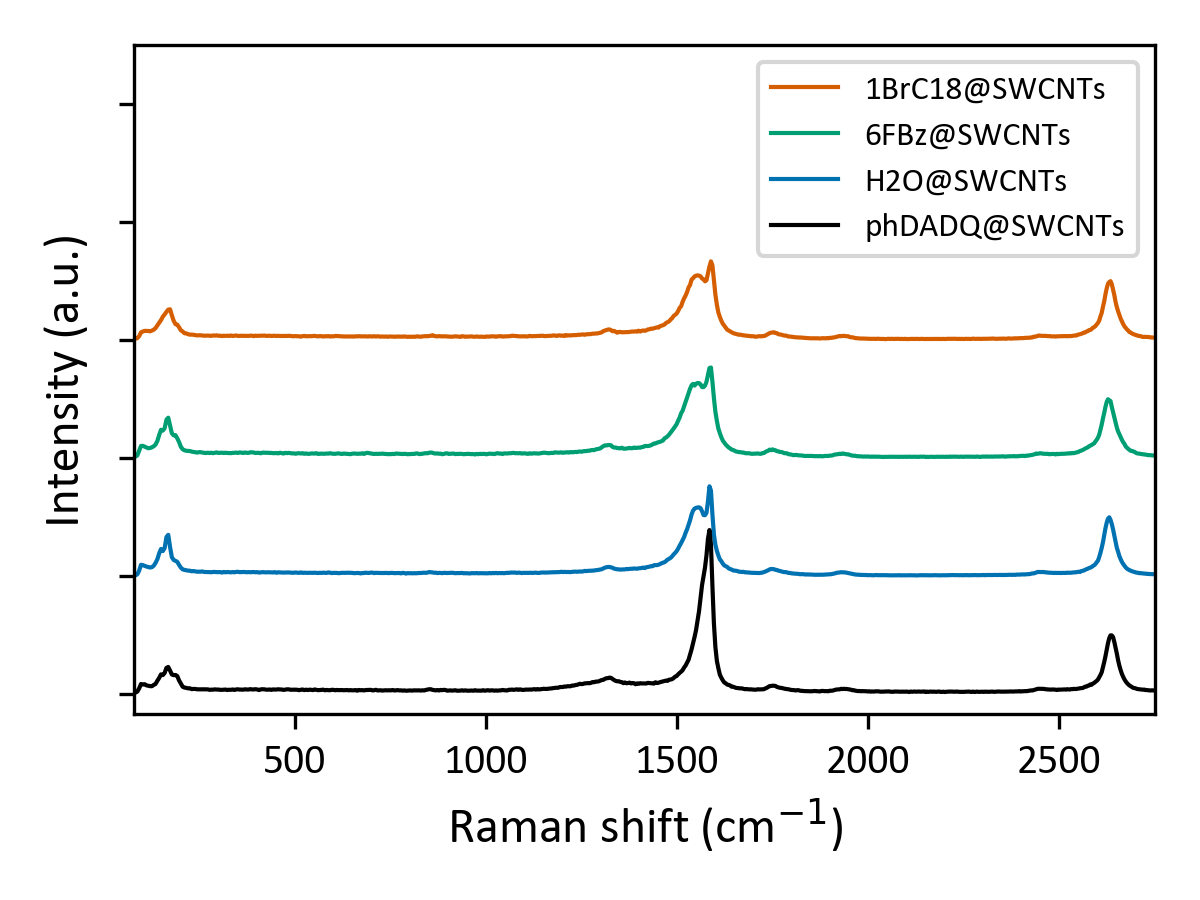

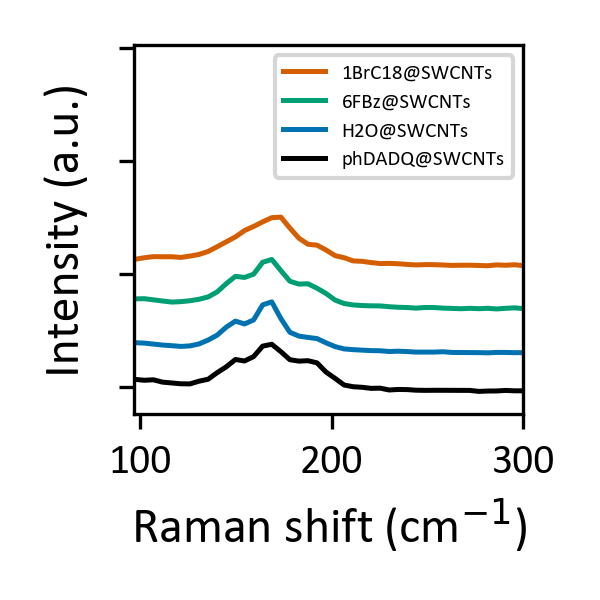

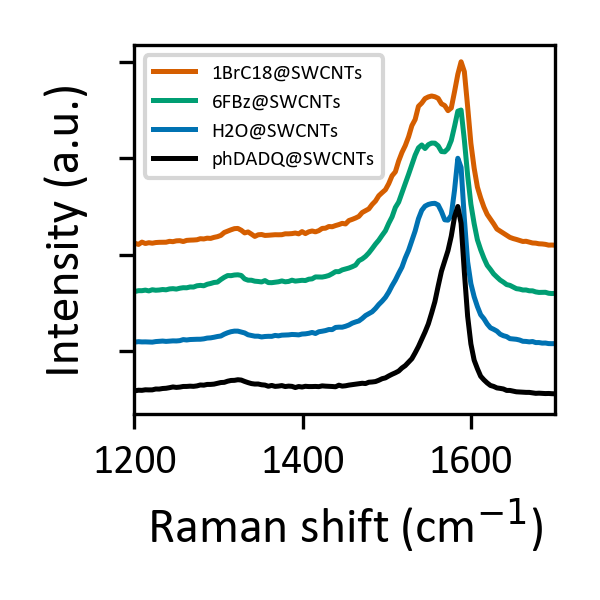

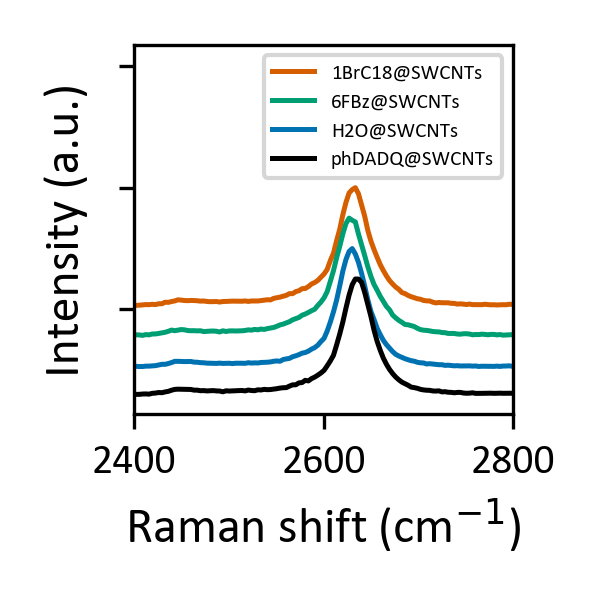

In [13]:
 #==============================================================================
# [ CELDA 9 ] : 638 nm - CFDrop (sc960_1) normalizada por D-Band
# ==============================================================================
raman_config_638_sc960 = [
    ("260818_F007WA_1BrC18@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt", "1BrC18@SWCNTs", "#D55E00", "-"),
    ("260818_F006WA_phDADQ@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt", "phDADQ@SWCNTs", "#000000", "-"),
    ("260818_F005LP_6FBz@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",   "6FBz@SWCNTs",   "#009E73", "-"),
    ("260818_P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960_1.txt",             "H2O@SWCNTs",    "#0072B2", "-"),
]

poster_style = {
    "figsize": (4,3), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

PlotRamanConfig(
    config=raman_config_638_sc1870, 
    spectra_dict=raman_spectra, 
    style=poster_style,
    offset_step=-2, 
    #ymax=5,
    norm_xmin=2400,     
    norm_xmax=2800,
    hide_yticks=True,
    xmin=80,
    xmax=2750,
    ymax=5,
)


poster_style = {
    "figsize": (2,2), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 5,
    "line_width": 1.2,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

PlotRamanConfig(
    config=raman_config_638_sc1870, 
    spectra_dict=raman_spectra, 
    style=poster_style,
    offset_step=-0.75, 
    #ymax=5,
    norm_xmin=97,     
    norm_xmax=300,
    hide_yticks=True,
    xmin=97,
    xmax=300
)


poster_style = {
    "figsize": (2,2), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 5,
    "line_width": 1.2,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

PlotRamanConfig(
    config=raman_config_638_sc1870, 
    spectra_dict=raman_spectra,
    style=poster_style,
    offset_step=-0.25,
    #ymax=5,
    norm_xmin=1200,     
    norm_xmax=1700,
    hide_yticks=True,
    xmin=1200,
    xmax=1700
)

poster_style = {
    "figsize": (2,2), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 5,
    "line_width": 1.2,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

PlotRamanConfig(
    config=raman_config_638_sc1870, 
    spectra_dict=raman_spectra, 
    style=poster_style,
    offset_step=-0.25,
    #ymax=5,
    norm_xmin=2400,     
    norm_xmax=2800,
    hide_yticks=True,
    xmin=2400,
    xmax=2800
)
